Title and Introduction
# PageRank Algorithm: Implementation and Mathematical Analysis

## 1. Introduction
The internet is a vast, interconnected network of information. In the early days of the web, finding relevant information was incredibly difficult because search engines primarily ranked pages based on keyword density. The PageRank algorithm, developed by Larry Page and Sergey Brin, revolutionized this process by evaluating the quality and quantity of links to a webpage to determine a relative score of that page's importance and authority. 

This project explores the mathematical underpinnings of PageRank, demonstrating how a real-world problem—information retrieval and ranking—can be translated into a mathematical counterpart and solved programmatically.

Problem Formulation
## 2. Problem Formulation and Significance

**The Real-World Problem:** Given billions of web pages, how can a search engine determine which pages are the most authoritative and relevant to display first? 

**The Mathematical Translation:**
We can model the World Wide Web as a massive directed graph. In this graph, each web page is a node, and each hyperlink from one page to another is a directed edge. The core assumption of PageRank is that more important websites are likely to receive more links from other websites. Therefore, the problem of ranking web pages transforms into the mathematical problem of finding the steady-state probability distribution of a random surfer clicking links on this directed graph. 

Understanding and solving this problem is highly significant, as it forms the foundational logic for modern search engines and network analysis.

Project Scope and Objectives
## 3. Project Scope and Objectives

The objective of this notebook is to build the PageRank algorithm from scratch and analyze its behavior. Specifically, this project will cover:

* **Mathematical Foundation:** Explaining the linear algebra behind the algorithm, including transition matrices, Markov chains, and eigenvectors.
* **Data Simulation:** Generating localized, mock network graphs to serve as our web environment.
* **Algorithm Implementation:** Writing a functional Python implementation of the iterative PageRank algorithm.
* **Analysis and Validation:** Testing the algorithm's convergence, analyzing the impact of the damping factor ($d$), and discussing edge cases like "spider traps" and "dead ends."


In [2]:
%pip install numpy networkx matplotlib

   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/12.3 MB 8.4 MB/s eta 0:00:02
   ---------- ----------------------------- 3.1/12.3 MB 7.8 MB/s eta 0:00:02
   -------------- ------------------------- 4.5/12.3 MB 7.4 MB/s eta 0:00:02
   ------------------- -------------------- 6.0/12.3 MB 7.3 MB/s eta 0:00:01
   ---------------------- ----------------- 7.1/12.3 MB 7.0 MB/s eta 0:00:01
   -------------------------- ------------- 8.1/12.3 MB 6.7 MB/s eta 0:00:01
   ----------------------------- ---------- 9.2/12.3 MB 6.6 MB/s eta 0:00:01
   ---------------------------------- ----- 10.7/12.3 MB 6.5 MB/s eta 0:00:01
   -------------------------------------- - 11.8/12.3 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------- 12.3/12.3 MB 6.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ----------------------------------- ---- 1.8/2.1 MB 9.2 MB/s eta 0:00:01
   ---------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

np.random.seed(42)

print("Libraries successfully imported. Environment ready for PageRank implementation.")

Libraries successfully imported. Environment ready for PageRank implementation.


Transition Matrices
## 4. Mathematical Foundation

To compute the PageRank of a network, we must translate our web graph into a mathematical structure. We do this using a **Transition Matrix** (often denoted as $M$). 

Let $N$ be the total number of pages on our web graph. The matrix $M$ is an $N \times N$ matrix where each column represents a web page, and each row represents an outgoing link. 

If page $j$ has $L(j)$ outgoing links, the probability of a user clicking any specific link on that page is $\frac{1}{L(j)}$. Therefore, the entries of our transition matrix are defined as:

$$M_{ij} = \begin{cases} \frac{1}{L(j)} & \text{if page } j \text{ links to page } i \\ 0 & \text{otherwise} \end{cases}$$

This creates a "column stochastic matrix," meaning the sum of probabilities in every column equals 1 (assuming the page has at least one outgoing link).

The Damping Factor
### 4.1. The Random Surfer Model and Damping Factor

If a user endlessly clicks links, what happens if they reach a page with no outgoing links (a "dead end") or a group of pages that only link to each other (a "spider trap")? They would get stuck, and the math would break.

To solve this, Larry Page and Sergey Brin introduced the **Random Surfer Model** and the **Damping Factor** ($d$). 

The damping factor represents the probability that a user will continue clicking links. The value $(1 - d)$ represents the probability that the user gets bored and "teleports" to a completely random page in the network. Traditionally, $d$ is set to $0.85$.

Taking the damping factor into account, the PageRank $PR$ of a specific page $p_i$ is calculated as:

$$PR(p_i) = \frac{1-d}{N} + d \sum_{p_j \in M(p_i)} \frac{PR(p_j)}{L(p_j)}$$

Where $M(p_i)$ is the set of all pages that link to $p_i$.

Eigenvectors
### 4.2. Eigenvector Centrality

While the iterative summation above is intuitive, the most efficient way to compute PageRank mathematically is by finding the steady-state of the network.

If we represent the PageRank of all pages as a column vector $v$, the PageRank equation for the entire network can be expressed as:

$$v = \left( \frac{1-d}{N} E + d M \right) v$$

Where $E$ is an $N \times N$ matrix of ones. This equation essentially states that the PageRank vector $v$ is the **principal eigenvector** of the modified transition matrix, corresponding to an eigenvalue of 1. By repeatedly multiplying our transition matrix by our rank vector (the Power Iteration method), the values will eventually converge to this steady-state eigenvector.

Data Simulation Explanation
## 5. Data Simulation: Building a Network Graph

To test our PageRank algorithm, we need a network of web pages. [cite_start]As per the project guidelines, data for our analysis may be generated or simulated. 

We will use the `networkx` library to construct a small, directed graph representing five hypothetical web pages (A, B, C, D, and E). 

**Network Structure:**
* **Page A** is a highly referenced page (receives many links).
* **Page B** and **Page C** link back and forth to each other and to A.
* **Page D** only links to Page A.
* **Page E** is somewhat isolated, linking only to Page D.

Let's build and visualize this directed graph.

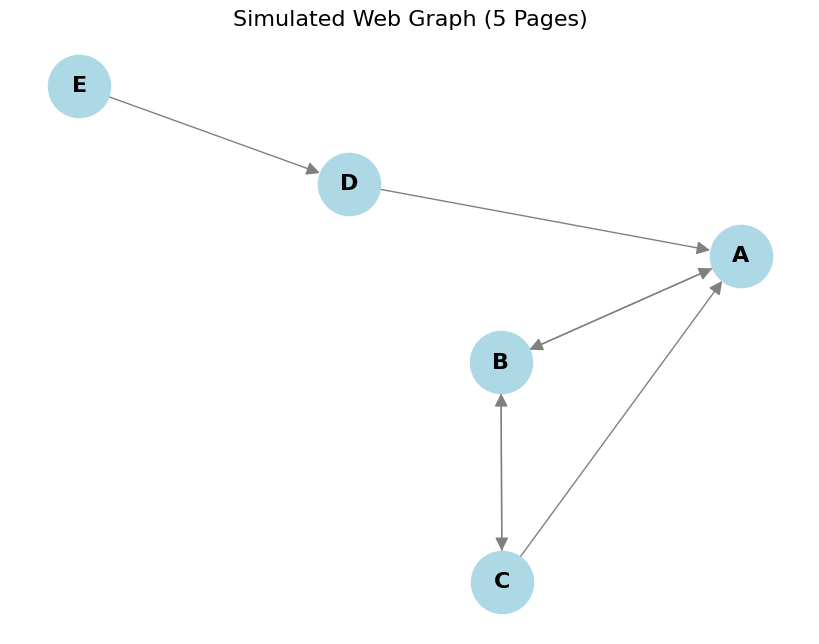

In [5]:
# Network Generation & Visualization
G = nx.DiGraph()


edges = [
    ('B', 'A'), ('B', 'C'),
    ('C', 'A'), ('C', 'B'),
    ('D', 'A'),
    ('E', 'D'),
    ('A', 'B') ]

G.add_edges_from(edges)

plt.figure(figsize=(8, 6))
pos = nx.spring_layout(G, seed=42) 

nx.draw(
    G, pos, 
    with_labels=True, 
    node_color='lightblue', 
    node_size=2000, 
    font_size=16, 
    font_weight='bold', 
    edge_color='gray', 
    arrowsize=20
)

plt.title("Simulated Web Graph (5 Pages)", fontsize=16)
plt.show()

Algorithm Implementation Explanation
## 6. Core Algorithm Implementation

Now we will implement the PageRank algorithm from scratch using the Power Iteration method. 

We will create a Python function that takes our directed graph, applies the initial probability of $\frac{1}{N}$ to all nodes, and then iteratively updates the scores based on the incoming links and the damping factor ($d = 0.85$). The loop will continue until the scores converge (meaning the change between iterations is smaller than our set tolerance) or until it hits the maximum number of iterations.

In [6]:
def compute_pagerank(graph, d=0.85, max_iterations=100, tolerance=1e-6):
    """
    Calculates the PageRank of nodes in a directed graph from scratch.
    
    Parameters:
    - graph: A networkx DiGraph object
    - d: Damping factor (default 0.85)
    - max_iterations: Maximum number of iterative updates (default 100)
    - tolerance: Threshold for convergence (default 1e-6)
    """
    N = graph.number_of_nodes()
    
    pagerank = {node: 1/N for node in graph.nodes()}
    
    for i in range(max_iterations):
        new_pagerank = {}
        total_diff = 0
        
        for node in graph.nodes():
            rank = (1 - d) / N
            
            for neighbor in graph.predecessors(node):
                out_degree = graph.out_degree(neighbor)
                if out_degree > 0:
                    rank += d * (pagerank[neighbor] / out_degree)
                    
            new_pagerank[node] = rank
            
            total_diff += abs(new_pagerank[node] - pagerank[node])
            
        pagerank = new_pagerank
        
        if total_diff < tolerance:
            print(f"Algorithm converged successfully after {i+1} iterations.")
            break
            
    return pagerank

custom_pr_scores = compute_pagerank(G)

print("\nFinal Calculated PageRank Scores:")
sorted_pr = sorted(custom_pr_scores.items(), key=lambda item: item[1], reverse=True)
for node, score in sorted_pr:
    print(f"Page {node}: {score:.4f}")

Algorithm converged successfully after 21 iterations.

Final Calculated PageRank Scores:
Page B: 0.3913
Page A: 0.3269
Page C: 0.1963
Page D: 0.0555
Page E: 0.0300


Validation Explanation
## 7. Validation and Testing

[cite_start]To ensure our custom PageRank implementation is mathematically sound and follows best practices[cite: 132], we must validate its output. We will do this by comparing our generated scores against the highly optimized, built-in PageRank function provided by the `networkx` library. 

[cite_start]If our mathematical translation of the problem is correct[cite: 80], the difference between our custom scores and the library's scores should be effectively zero (within our established tolerance).

In [9]:
%pip install scipy

   ---------------------------------------- 0.0/36.5 MB ? eta -:--:--
   - -------------------------------------- 1.0/36.5 MB 6.8 MB/s eta 0:00:06
   --- ------------------------------------ 3.1/36.5 MB 8.8 MB/s eta 0:00:04
   ----- ---------------------------------- 5.0/36.5 MB 8.7 MB/s eta 0:00:04
   ------- -------------------------------- 6.8/36.5 MB 9.1 MB/s eta 0:00:04
   ---------- ----------------------------- 9.2/36.5 MB 9.1 MB/s eta 0:00:03
   ------------ --------------------------- 11.5/36.5 MB 9.7 MB/s eta 0:00:03
   -------------- ------------------------- 13.6/36.5 MB 9.5 MB/s eta 0:00:03
   ----------------- ---------------------- 16.0/36.5 MB 9.8 MB/s eta 0:00:03
   ------------------- -------------------- 17.6/36.5 MB 9.4 MB/s eta 0:00:03
   -------------------- ------------------- 18.9/36.5 MB 9.1 MB/s eta 0:00:02
   ---------------------- ----------------- 20.2/36.5 MB 8.9 MB/s eta 0:00:02
   ----------------------- ---------------- 21.2/36.5 MB 8.5 MB/s eta 0:00:02


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
nx_pr_scores = nx.pagerank(G, alpha=0.85)

print("--- Validation Results ---")
print(f"{'Node':<6} | {'Custom PR':<12} | {'NetworkX PR':<12} | {'Difference':<12}")
print("-" * 50)

for node in G.nodes():
    custom_score = custom_pr_scores[node]
    nx_score = nx_pr_scores[node]
    difference = abs(custom_score - nx_score)
    
    print(f"{node:<6} | {custom_score:<12.6f} | {nx_score:<12.6f} | {difference:<12.8f}")

max_diff = max(abs(custom_pr_scores[n] - nx_pr_scores[n]) for n in G.nodes())
if max_diff < 1e-5:
    print("\nSUCCESS: Custom implementation matches the NetworkX library! Validation passed.")
else:
    print("\nWARNING: Scores diverge significantly. Check the implementation logic.")

--- Validation Results ---
Node   | Custom PR    | NetworkX PR  | Difference  
--------------------------------------------------
B      | 0.391296     | 0.391295     | 0.00000085  
A      | 0.326904     | 0.326904     | 0.00000005  
C      | 0.196301     | 0.196301     | 0.00000080  
D      | 0.055500     | 0.055500     | 0.00000000  
E      | 0.030000     | 0.030000     | 0.00000000  

SUCCESS: Custom implementation matches the NetworkX library! Validation passed.


Complexity Analysis
## 8. Code Quality and Complexity Analysis

As part of writing production-ready code, it is essential to ensure separation of concerns and to analyze the efficiency of our algorithms.

### 8.1. Computational Complexity
The efficiency of our custom PageRank implementation can be analyzed using Big O notation:

* **Time Complexity:** The algorithm iterates a maximum of $I$ times (where $I$ is `max_iterations`). In each iteration, it loops through every node $V$ (vertices) and checks its incoming edges $E$. Therefore, the worst-case time complexity is $O(I \times (V + E))$. Because real-world web graphs are extremely sparse (most pages only link to a tiny fraction of the total internet), $E$ is generally proportional to $V$, making the practical time complexity roughly $O(I \times V)$.
* **Space Complexity:** We store the graph itself, plus two dictionaries (`pagerank` and `new_pagerank`) that hold a float value for each node. Thus, the space complexity is $O(V + E)$ to store the graph, and $O(V)$ for the PageRank calculations.

### 8.2. Refactoring for Maintainability
To adhere to coding best practices and make our codebase easier to maintain, we will encapsulate our hardcoded graph generation into a reusable Python function. This allows us to easily generate different network topologies in the future without cluttering our global scope.

In [ ]:
# Refactoring
def generate_custom_graph():
    """
    Generates a sample directed graph for PageRank testing.
    Ensures clear separation of concerns by isolating data generation logic.
    
    Returns:
        networkx.DiGraph: A directed graph with predefined nodes and edges.
    """
    graph = nx.DiGraph()
    
    edges = [
        ('B', 'A'), ('B', 'C'),
        ('C', 'A'), ('C', 'B'),
        ('D', 'A'),
        ('E', 'D'),
        ('A', 'B') 
    ]
    
    graph.add_edges_from(edges)
    return graph

test_graph = generate_custom_graph()
print(f"Graph generated successfully with {test_graph.number_of_nodes()} nodes and {test_graph.number_of_edges()} edges.")

Graph generated successfully with 5 nodes and 7 edges.


## 9. Data Visualization: Algorithm Convergence

To fully validate our methods and provide clear insights into our algorithm's behavior, we will visualize the convergence of the PageRank scores over multiple iterations. 

By tracking the score of each page at every step of the Power Iteration method, we can observe exactly how the "link juice" flows through our network until the system reaches its steady-state eigenvector. This satisfies the best practices for data processing and visual metric analysis.

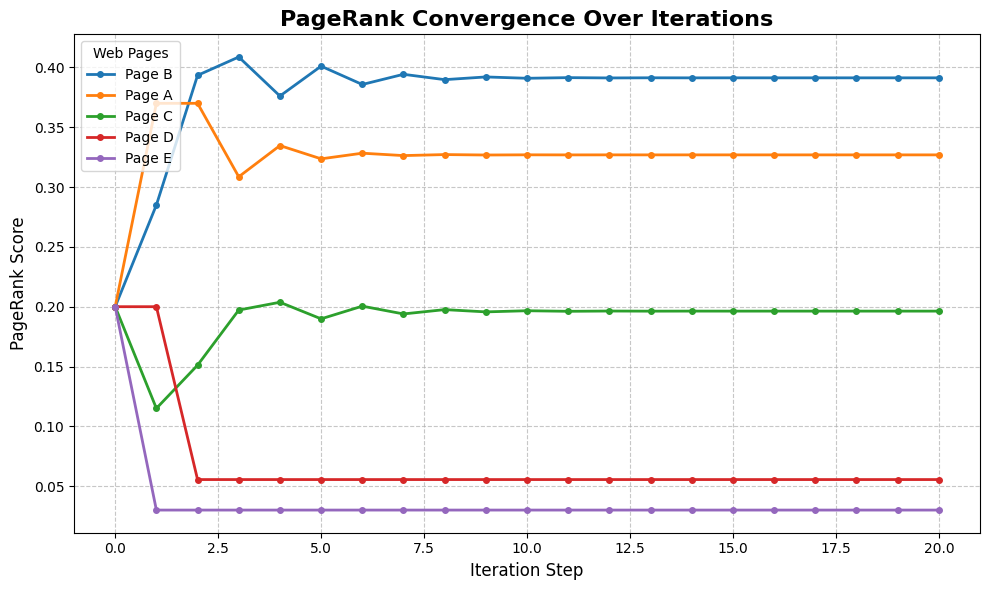

In [13]:
nodes = list(G.nodes())
N = len(nodes)
history = {node: [1/N] for node in nodes}
current_pr = {node: 1/N for node in nodes}
d = 0.85

for _ in range(20):
    next_pr = {}
    for node in nodes:
        rank = (1 - d) / N
        for neighbor in G.predecessors(node):
            out_degree = G.out_degree(neighbor)
            if out_degree > 0:
                rank += d * (current_pr[neighbor] / out_degree)
        next_pr[node] = rank
        
    current_pr = next_pr
    for node in nodes:
        history[node].append(current_pr[node])

plt.figure(figsize=(10, 6))

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
for i, node in enumerate(nodes):
    plt.plot(history[node], label=f'Page {node}', color=colors[i], linewidth=2, marker='o', markersize=4)

plt.title('PageRank Convergence Over Iterations', fontsize=16, fontweight='bold')
plt.xlabel('Iteration Step', fontsize=12)
plt.ylabel('PageRank Score', fontsize=12)
plt.legend(title='Web Pages')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()